# Creando nuestro propio KNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import warnings
from math import sqrt
from collections import Counter

In [2]:
dataset = {
    'k':[[1, 2], [2, 3], [3, 1]],
    'r': [[6, 5], [7, 7], [8, 6]]
}

new_point = [5, 7]

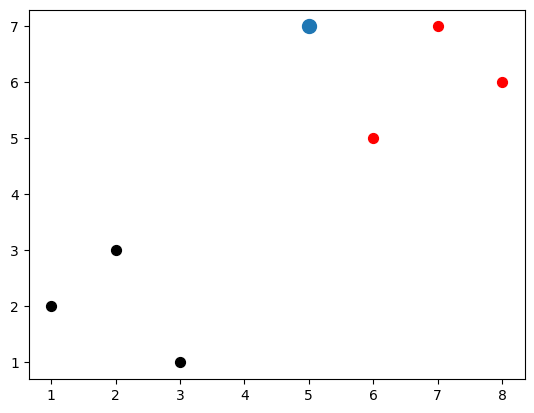

In [3]:
# Estar pendiente con esta sintaxis

[[plt.scatter(j[0], j[1], s = 50, color = i) for j in dataset[i]] for i in dataset]

# Representemos también el punto 'new_point'

plt.scatter(new_point[0], new_point[1], s = 100)

In [ ]:
def k_nearest_neighbors(data, predict, k = 3, verbose = False):

    if len(data) >= k:
        warnings.warn("K es un valor menor que el número total de elementos a votar!!")

    distances = []

    for group in data:
        for point in data[group]:
            # d = sqrt((point[0]-predict[0])**2 + (point[1]-predict[1])**2)
            # d = np.sqrt(np.sum((np.array(point) - np.array(predict))**2))
            d = np.linalg.norm(np.array(point) - np.array(predict))
            distances.append([d, group])

    if verbose:
        print(distances)

    votes = [i[1] for i in sorted(distances)[:k]] # sorted ordena por la primera columna

    if verbose:
        print(votes)

    vote_result = Counter(votes).most_common(1)

    if verbose:
        print(vote_result)

    return vote_result[0][0] # [('r',2), ('k', 1)]

In [ ]:
new_point = [4, 4.5]
result = k_nearest_neighbors(dataset, [new_point])
result

'k'

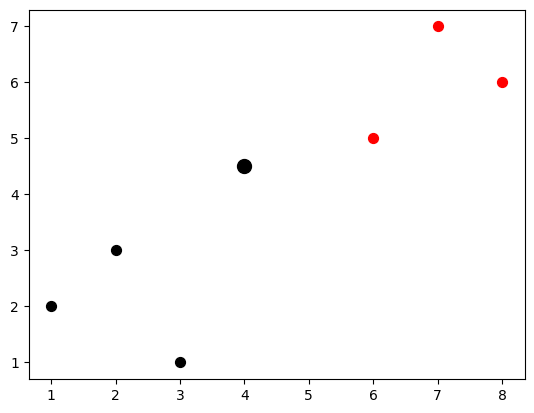

In [ ]:
[[plt.scatter(j[0], j[1], s = 50, color = i) for j in dataset[i]] for i in dataset]
plt.scatter(new_point[0], new_point[1], s = 100, color = result)

# Aplicando nuestro KNN al Dataset del Cancer

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/cancer/breast-cancer-wisconsin.data.txt')

In [ ]:
df.replace("?", -99999, inplace = True)

In [ ]:
df.columns = ["Id", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "class"]

In [ ]:
df.drop(["Id"], 1, inplace = True)

<ipython-input-11-5d58e1949638>:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df.drop(["Id"], 1, inplace=True)


In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,class
0,5,4,4,5,7,10,3,2,1,2
1,3,1,1,1,2,2,3,1,1,2
2,6,8,8,1,3,4,3,7,1,2
3,4,1,1,3,2,1,3,1,1,2
4,8,10,10,8,7,10,9,7,1,4


In [ ]:
full_data = df.astype(float).values.tolist()
full_data

[[5.0, 4.0, 4.0, 5.0, 7.0, 10.0, 3.0, 2.0, 1.0, 2.0],
 [3.0, 1.0, 1.0, 1.0, 2.0, 2.0, 3.0, 1.0, 1.0, 2.0],
 [6.0, 8.0, 8.0, 1.0, 3.0, 4.0, 3.0, 7.0, 1.0, 2.0],
 [4.0, 1.0, 1.0, 3.0, 2.0, 1.0, 3.0, 1.0, 1.0, 2.0],
 [8.0, 10.0, 10.0, 8.0, 7.0, 10.0, 9.0, 7.0, 1.0, 4.0],
 [1.0, 1.0, 1.0, 1.0, 2.0, 10.0, 3.0, 1.0, 1.0, 2.0],
 [2.0, 1.0, 2.0, 1.0, 2.0, 1.0, 3.0, 1.0, 1.0, 2.0],
 [2.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 5.0, 2.0],
 [4.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 2.0],
 [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 1.0, 1.0, 2.0],
 [2.0, 1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 2.0],
 [5.0, 3.0, 3.0, 3.0, 2.0, 3.0, 4.0, 4.0, 1.0, 4.0],
 [1.0, 1.0, 1.0, 1.0, 2.0, 3.0, 3.0, 1.0, 1.0, 2.0],
 [8.0, 7.0, 5.0, 10.0, 7.0, 9.0, 5.0, 5.0, 4.0, 4.0],
 [7.0, 4.0, 6.0, 4.0, 6.0, 1.0, 4.0, 3.0, 1.0, 4.0],
 [4.0, 1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 2.0],
 [4.0, 1.0, 1.0, 1.0, 2.0, 1.0, 3.0, 1.0, 1.0, 2.0],
 [10.0, 7.0, 7.0, 6.0, 4.0, 10.0, 4.0, 1.0, 2.0, 4.0],
 [6.0, 1.0, 1.0, 1.0, 2.0, 1.0, 3.0, 1

In [ ]:
import random

In [ ]:
random.shuffle(full_data)

In [ ]:
test_size = 0.2

In [ ]:
train_set = {2:[],4:[]}
test_set = {2:[], 4:[]}

In [ ]:
train_data= full_data[:-int(test_size*len(full_data))]
test_data = full_data[-int(test_size*len(full_data)):]

In [ ]:
for i in train_data:
    train_set[i[-1]].append(i[:-1])

for i in test_data:
    test_set[i[-1]].append(i[:-1])

In [ ]:
correct = 0
total = 0
for group in test_set:
    for data in test_set[group]:
        vote = k_nearest_neighbors(train_set, data, k = 5)
        if group == vote:
            correct += 1
        total +=1
print("Eficacia del KNN = ",correct/total)

Eficacia del KNN =  0.9496402877697842
